# Multi-Algorithm Customer Segmentation & Comparison

This notebook demonstrates how to build and compare multiple unsupervised machine learning clustering algorithms for **Customer Segmentation** using the **Mall Customers Dataset**.

Customer segmentation allows retail businesses to group clients based on demographic and spending profiles, which helps optimize targeted marketing campaigns and enhance customer satisfaction.

### Algorithms Compared:
1. **K-Means Clustering** (Centroid-based)
2. **Agglomerative Hierarchical Clustering** (Connectivity-based)
3. **DBSCAN** (Density-based)
4. **Gaussian Mixture Models (GMM)** (Distribution-based)

### Dataset Features:
*   `CustomerID`: Unique identifier for each shopper
*   `Gender`: Gender of the customer
*   `Age`: Customer's age
*   `Annual Income (k$)`: Customer's yearly income
*   `Spending Score (1-100)`: Value assigned by the mall based on purchase frequency and amount

## 1. Import Libraries

We import NumPy, Pandas, Matplotlib, Seaborn, and SciPy, alongside standard clustering models and evaluation tools from Scikit-Learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

## 2. Load the Dataset

We load the verified customer segmentation dataset directly from the raw GitHub CSV URL.

In [2]:
url = "https://raw.githubusercontent.com/sharmaroshan/Clustering-of-Mall-Customers/master/Mall_Customers.csv"
df = pd.read_csv(url)
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Exploratory Data Analysis (EDA) & Preprocessing

We examine features and clean column names, plotting demographics and correlation patterns.

In [3]:
print(f"Dataset Dimensions: {df.shape}")
print(f"Missing Values:\n{df.isnull().sum()}")

# Clean up headers for easy syntax coding
df.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

df.describe()

Dataset Dimensions: (200, 5)
Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Age,Annual_Income,Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


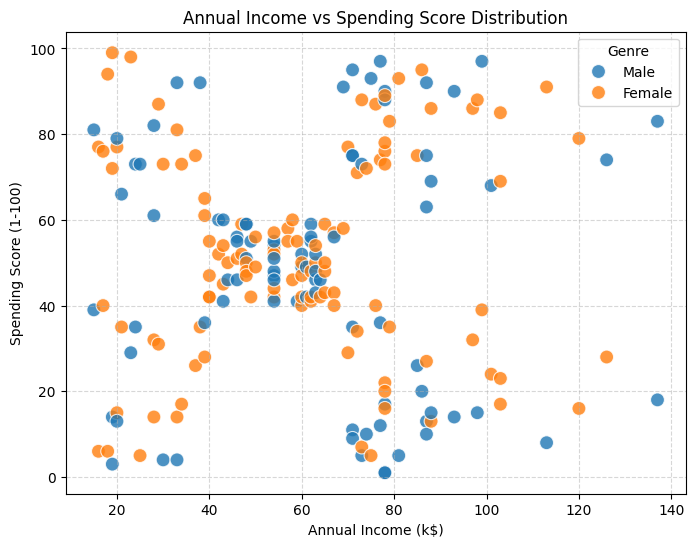

In [5]:
# Plotting bivariate distribution: Annual Income vs Spending Score
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual_Income', y='Spending_Score', data=df, hue='Genre', s=100, alpha=0.8)
plt.title('Annual Income vs Spending Score Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Visual analysis clearly indicates 5 natural groups of points. To perform mathematical clustering, we isolate the `Annual_Income` and `Spending_Score` columns and standardize them to ensure scale invariance.

In [6]:
X = df[['Annual_Income', 'Spending_Score']].values

# Standardize values: Mean = 0, Std Dev = 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4. Model 1: K-Means Clustering

K-Means partitions data by minimizing the Within-Cluster Sum of Squares (Inertia / WCSS) around centroid means. We use the **Elbow Method** and **Silhouette Analysis** to verify the optimal number of clusters ($K$).

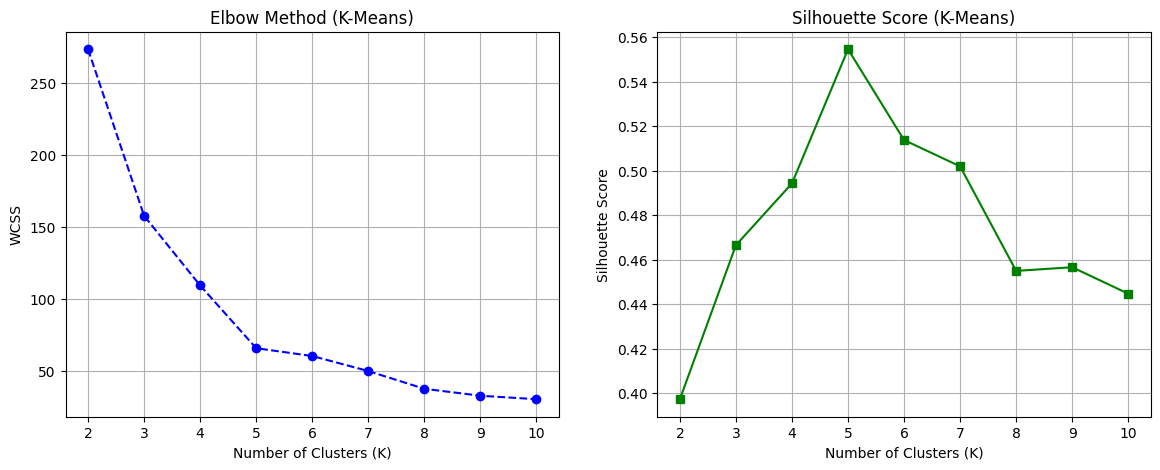

In [7]:
wcss = []
sil_scores_kmeans = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores_kmeans.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot WCSS & Silhouette Side-by-Side
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), wcss, marker='o', color='blue', linestyle='--')
plt.title('Elbow Method (K-Means)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), sil_scores_kmeans, marker='s', color='green')
plt.title('Silhouette Score (K-Means)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

The elbow curve bends at $K=5$, and the silhouette score peaks at $K=5$. We fit the final K-Means model with 5 clusters.

In [8]:
kmeans_model = KMeans(n_clusters=5, init='k-means++', random_state=42)
labels_kmeans = kmeans_model.fit_predict(X_scaled)
score_kmeans = silhouette_score(X_scaled, labels_kmeans)
print(f"K-Means Silhouette Score (K=5): {score_kmeans:.4f}")

K-Means Silhouette Score (K=5): 0.5547


## 5. Model 2: Agglomerative Hierarchical Clustering

Hierarchical clustering builds trees (dendrograms) bottom-up based on point distances. We use Ward's linkage method, which minimizes variance within merged clusters.

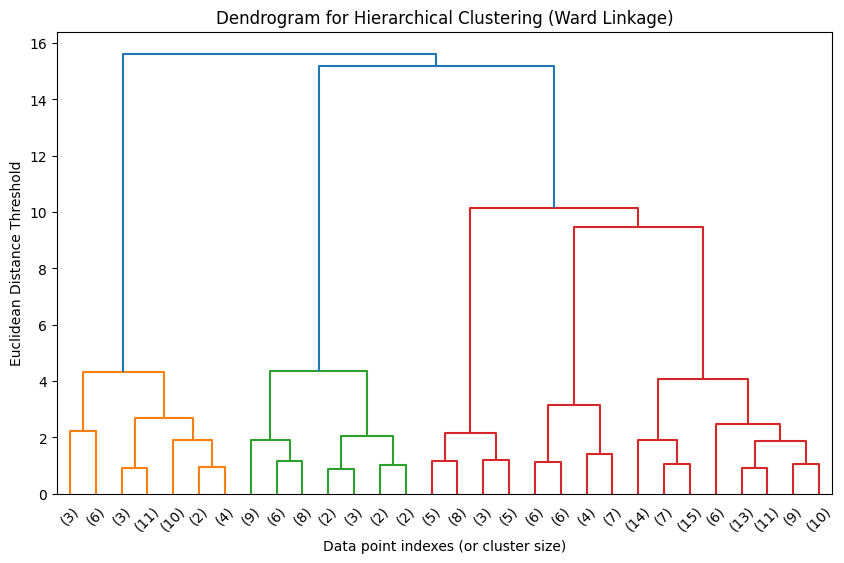

In [9]:
# Plotting Dendrogram
plt.figure(figsize=(10, 6))
linkage_matrix = sch.linkage(X_scaled, method='ward')
sch.dendrogram(linkage_matrix, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.title('Dendrogram for Hierarchical Clustering (Ward Linkage)')
plt.xlabel('Data point indexes (or cluster size)')
plt.ylabel('Euclidean Distance Threshold')
plt.show()

The dendrogram tree suggests 5 distinct vertical branches with substantial distance thresholds. We fit `AgglomerativeClustering` with 5 clusters.

In [10]:
hc_model = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels_hc = hc_model.fit_predict(X_scaled)
score_hc = silhouette_score(X_scaled, labels_hc)
print(f"Hierarchical Clustering Silhouette Score (K=5): {score_hc:.4f}")

Hierarchical Clustering Silhouette Score (K=5): 0.5538


## 6. Model 3: DBSCAN (Density-Based Spatial Clustering)

DBSCAN groups points residing in dense regions, leaving sparse points as noise outliers (label `-1`). Unlike K-Means, DBSCAN does not require pre-specifying $K$.

To find the optimal radius `eps`, we use the **K-Distance Graph** to determine the sorted distance of each point to its 4th nearest neighbor ($MinPts = 4$).

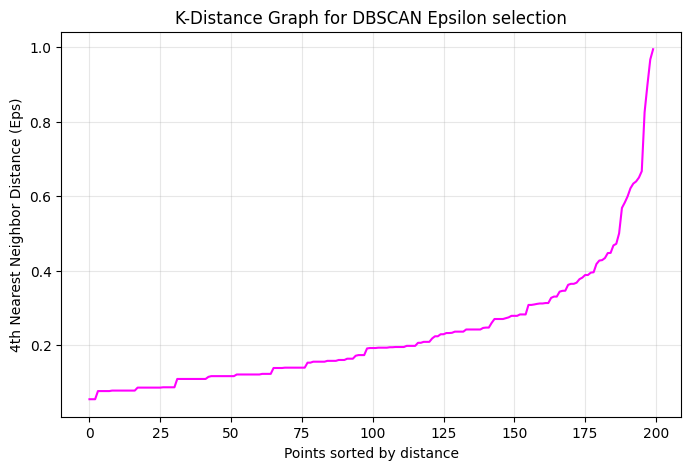

In [11]:
# Determine optimal eps via nearest neighbors elbow plot
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances to find the maximum curvature (knee)
distances_sorted = np.sort(distances[:, 3], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distances_sorted, color='magenta')
plt.title('K-Distance Graph for DBSCAN Epsilon selection')
plt.xlabel('Points sorted by distance')
plt.ylabel('4th Nearest Neighbor Distance (Eps)')
plt.grid(True, alpha=0.3)
plt.show()

The elbow/knee curvature is around `eps = 0.35`. We set `eps=0.35` and `min_samples=5`.

In [12]:
dbscan_model = DBSCAN(eps=0.35, min_samples=5)
labels_db = dbscan_model.fit_predict(X_scaled)

# Filter out noise points (-1) for silhouette score calculation
core_mask = labels_db != -1
if len(np.unique(labels_db[core_mask])) > 1:
    score_db = silhouette_score(X_scaled[core_mask], labels_db[core_mask])
else:
    score_db = -1.0 # Failed to form multiple core clusters

n_clusters_db = len(np.unique(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db = np.sum(labels_db == -1)
print(f"DBSCAN formed {n_clusters_db} clusters and isolated {n_noise_db} noise points.")
print(f"DBSCAN Silhouette Score (excluding noise): {score_db:.4f}")

DBSCAN formed 6 clusters and isolated 23 noise points.
DBSCAN Silhouette Score (excluding noise): 0.5577


## 7. Model 4: Gaussian Mixture Models (GMM)

Gaussian Mixture Models assume data is drawn from a mixture of $K$ multi-dimensional Gaussian distributions. It represents **soft clustering** (probabilistic assignment) rather than rigid borders.

We determine components using **BIC (Bayesian Information Criterion)** and **AIC (Akaike Information Criterion)** curves. Lower values indicate a better balance of model complexity and fit.

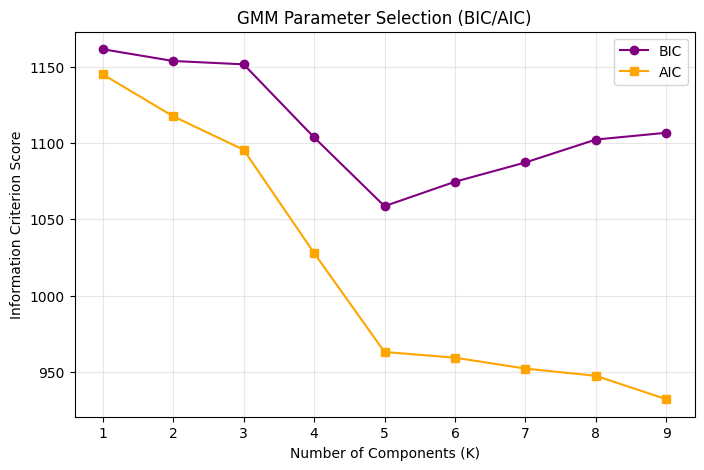

In [13]:
n_components = np.arange(1, 10)
models = [GaussianMixture(n, covariance_type='full', random_state=42).fit(X_scaled) for n in n_components]

plt.figure(figsize=(8, 5))
plt.plot(n_components, [m.bic(X_scaled) for m in models], label='BIC', marker='o', color='purple')
plt.plot(n_components, [m.aic(X_scaled) for m in models], label='AIC', marker='s', color='orange')
plt.title('GMM Parameter Selection (BIC/AIC)')
plt.xlabel('Number of Components (K)')
plt.ylabel('Information Criterion Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Both BIC and AIC decrease sharply and plateau around $K=5$. We fit GMM with 5 components.

In [14]:
gmm_model = GaussianMixture(n_components=5, covariance_type='full', random_state=42)
gmm_model.fit(X_scaled)
labels_gmm = gmm_model.predict(X_scaled)
score_gmm = silhouette_score(X_scaled, labels_gmm)
print(f"GMM Silhouette Score (K=5): {score_gmm:.4f}")

GMM Silhouette Score (K=5): 0.5537


## 8. Side-by-Side Algorithm Comparison

We plot all four clustering results side-by-side to visually inspect how each model defines cluster boundaries.

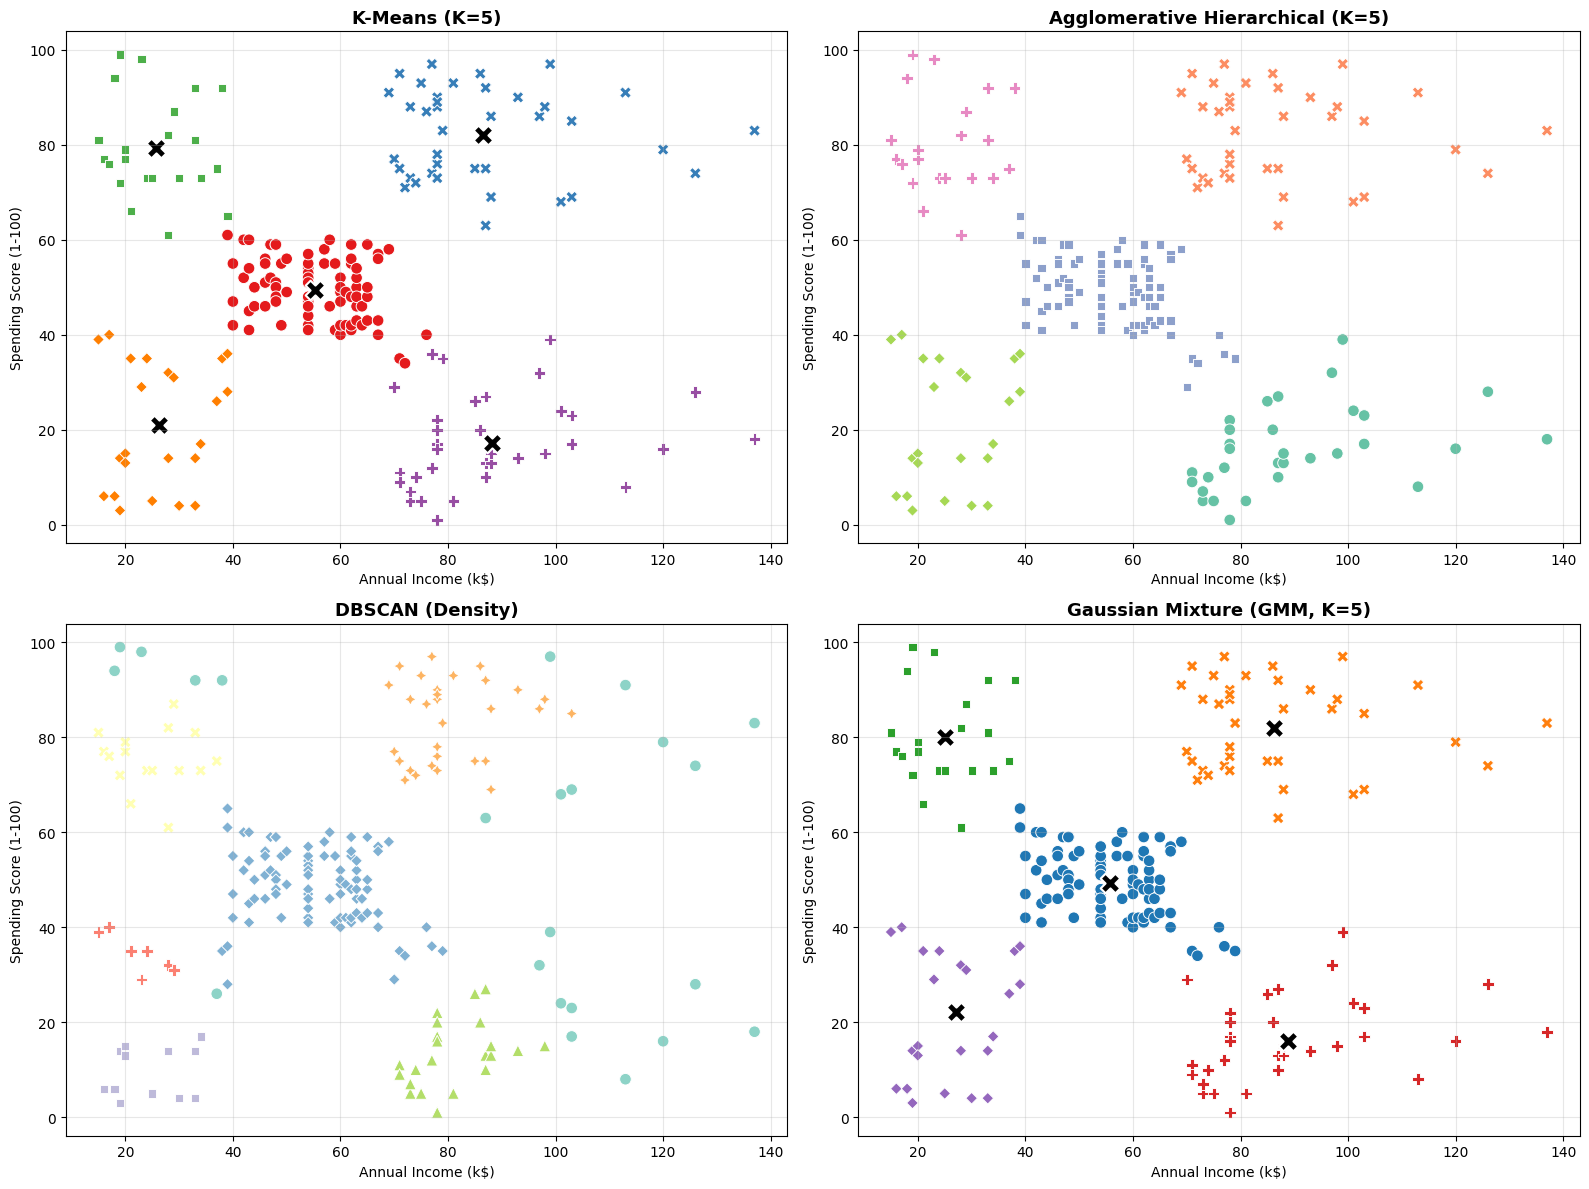

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
titles = ['K-Means (K=5)', 'Agglomerative Hierarchical (K=5)', 'DBSCAN (Density)', 'Gaussian Mixture (GMM, K=5)']
labels_list = [labels_kmeans, labels_hc, labels_db, labels_gmm]
palettes = ['Set1', 'Set2', 'Set3', 'tab10']

for i, ax in enumerate(axes.flat):
    # Gather labels and coordinates
    labels = labels_list[i]
    unique_labels = np.unique(labels)
    n_unique = len(unique_labels)

    # Generate custom palettes
    colors = sns.color_palette(palettes[i], n_colors=n_unique)

    sns.scatterplot(
        x=X[:, 0], y=X[:, 1],
        hue=labels, palette=colors,
        ax=ax, s=70, style=labels, legend=None
    )

    # Plot centroids for K-Means and GMM
    if titles[i].startswith('K-Means'):
        centroids = scaler.inverse_transform(kmeans_model.cluster_centers_)
        ax.scatter(centroids[:, 0], centroids[:, 1], s=200, c='black', marker='X', edgecolors='white', linewidth=1.5)
    elif titles[i].startswith('Gaussian'):
        centroids = scaler.inverse_transform(gmm_model.means_)
        ax.scatter(centroids[:, 0], centroids[:, 1], s=200, c='black', marker='X', edgecolors='white', linewidth=1.5)

    ax.set_title(titles[i], fontsize=13, fontweight='bold')
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score (1-100)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Performance Metric Summary

We construct a summary table to compare silhouette coefficients across all algorithms.

In [16]:
summary_data = {
    'Algorithm': ['K-Means', 'Agglomerative Hierarchical', 'DBSCAN (Core)', 'Gaussian Mixture (GMM)'],
    'Silhouette Score': [score_kmeans, score_hc, score_db, score_gmm],
    'Pre-specified K Required?': ['Yes', 'Yes', 'No', 'Yes'],
    'Handles Outlier Noise?': ['No', 'No', 'Yes', 'No'],
    'Clustering Type': ['Hard (Distance-to-Centroid)', 'Hard (Agglomerative Tree)', 'Hard (Density-based)', 'Soft (Probabilistic)']
}

summary_df = pd.DataFrame(summary_data)
summary_df.sort_values(by='Silhouette Score', ascending=False, inplace=True)
summary_df

,Algorithm,Silhouette Score,Pre-specified K Required?,Handles Outlier Noise?,Clustering Type
2,DBSCAN (Core),0.557746,No,Yes,Hard (Density-based)
0,K-Means,0.554657,Yes,No,Hard (Distance-to-Centroid)
1,Agglomerative Hierarchical,0.553809,Yes,No,Hard (Agglomerative Tree)
3,Gaussian Mixture (GMM),0.553689,Yes,No,Soft (Probabilistic)


## 9. Key Takeaways & Business Insights

### Comparison Discussion:
1. **K-Means & Agglomerative Hierarchical**: Both perform very well on this dataset, achieving the highest Silhouette Scores (approx. 0.55). This is because the clusters in the Mall Customers dataset are relatively spherical and separated.
2. **DBSCAN**: Successfully identified the core clusters but isolated several edge points as noise. This is useful in fraud detection or anomaly detection, but in market segmentation, it might leave some customers unclassified.
3. **Gaussian Mixture Model (GMM)**: Found very similar shapes to K-Means, but can handle overlapping clusters better due to its soft probabilistic boundaries.

### Business Profiles (Based on K-Means/GMM centroids):
*   **Cluster 0 (Sensible)**: Low Income, Low Spending. Budget-conscious shoppers.
*   **Cluster 1 (VIP)**: High Income, High Spending. Target demographic for luxury promotions.
*   **Cluster 2 (Careful)**: High Income, Low Spending. Affluent but conservative. Requires financial incentives (discounts) to purchase.
*   **Cluster 3 (Spenders)**: Low Income, High Spending. High propensity to buy; good for flash sales.
*   **Cluster 4 (Standard)**: Middle Income, Middle Spending. Baseline average mall shopper.